In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit_noise import (
    compare_ideal_and_noisy_bb84_case,
    run_qiskit_noise_sweep
)

In [2]:
result = compare_ideal_and_noisy_bb84_case(
    alice_bit=0,
    alice_basis="X",
    bob_basis="X",
    single_qubit_gate_error=0.05,
    readout_error=0.05,
    shots=2000
)

print("Alice bit:", result["alice_bit"])
print("Alice basis:", result["alice_basis"])
print("Bob basis:", result["bob_basis"])
print("Ideal counts:", result["ideal_counts"])
print("Noisy counts:", result["noisy_counts"])
print("Ideal error probability:", result["ideal_error_probability"])
print("Noisy error probability:", result["noisy_error_probability"])

Alice bit: 0
Alice basis: X
Bob basis: X
Ideal counts: {'0': 2000}
Noisy counts: {'0': 1794, '1': 206}
Ideal error probability: 0.0
Noisy error probability: 0.103


In [3]:
noise_probabilities = np.linspace(0, 0.20, 11)

df = run_qiskit_noise_sweep(
    noise_probabilities=noise_probabilities,
    shots=2000,
    alice_bit=0,
    alice_basis="X",
    bob_basis="X"
)

df

,noise_probability,alice_bit,alice_basis,bob_basis,shots,ideal_prob_1,noisy_prob_1,ideal_error_probability,noisy_error_probability
0,0.00,0,X,X,2000,0.0,0.0000,0.0,0.0000
1,0.02,0,X,X,2000,0.0,0.0415,0.0,0.0415
2,0.04,0,X,X,2000,0.0,0.0750,0.0,0.0750
3,0.06,0,X,X,2000,0.0,0.1160,0.0,0.1160
4,0.08,0,X,X,2000,0.0,0.1510,0.0,0.1510
5,0.10,0,X,X,2000,0.0,0.1755,0.0,0.1755
6,0.12,0,X,X,2000,0.0,0.2085,0.0,0.2085
7,0.14,0,X,X,2000,0.0,0.2330,0.0,0.2330
8,0.16,0,X,X,2000,0.0,0.2610,0.0,0.2610
9,0.18,0,X,X,2000,0.0,0.2735,0.0,0.2735


In [4]:
df.to_csv("../results/qiskit_noise_results.csv", index=False)

print("Saved results to ../results/qiskit_noise_results.csv")

Saved results to ../results/qiskit_noise_results.csv


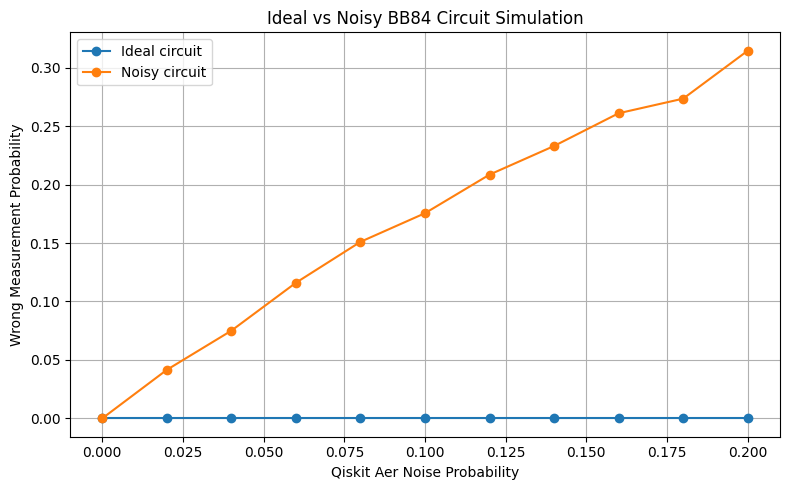

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    df["noise_probability"],
    df["ideal_error_probability"],
    marker="o",
    label="Ideal circuit"
)

plt.plot(
    df["noise_probability"],
    df["noisy_error_probability"],
    marker="o",
    label="Noisy circuit"
)

plt.xlabel("Qiskit Aer Noise Probability")
plt.ylabel("Wrong Measurement Probability")
plt.title("Ideal vs Noisy BB84 Circuit Simulation")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../figures/qiskit_noise_comparison.png", dpi=300)
plt.show()

# Qiskit Aer Noise Model Experiment

This notebook compares ideal and noisy BB84 circuit simulations using Qiskit Aer.

Earlier project versions modeled channel noise at the protocol level using a simple bit-flip probability. This version adds a circuit-level noise experiment using Qiskit Aer noise models.

The experiment uses a same-basis BB84 case where Alice prepares a bit and Bob measures in the same basis. In the ideal circuit, Bob should recover Alice's bit. As gate and readout noise increase, the probability of measuring the wrong bit also increases.